# Video Game Sales Analysis

## Objective

The purpose of this project is to clean,  
analyze and visualize video game sales   
data using Pandas, NumPy and Matplotlib.

# Data Loading

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('VideoGamesSales.csv')

# Data Overview

In [3]:
df.head()

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,$41.49,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,$29.08,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,$15.85,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,$15.75,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,$11.27,31.37,3.381,9.411


In [4]:
df.describe()

,Rank,Year,Global_Sales,NA_Profit,Global_Profit
count,5909.000000,5909.000000,5909.000000,5909.000000,5909.000000
mean,2943.953461,2013.197834,1.344519,0.198809,0.403356
std,1704.649477,2.223609,2.526125,0.400008,0.757837
min,1.000000,2010.000000,0.300000,0.000000,0.090000
25%,1469.000000,2011.000000,0.440000,0.060000,0.132000
50%,2943.000000,2013.000000,0.690000,0.108000,0.207000
75%,4420.000000,2015.000000,1.330000,0.204000,0.399000
max,5894.000000,2017.000000,82.740000,12.447000,24.822000


In [5]:
print(df.shape[0]) #count of rows
print(df.shape[1]) #count of columns

5909
15


In [6]:
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col:15} → {unique_count} unique values")

Rank            → 5893 unique values
Name            → 4139 unique values
Platform        → 26 unique values
Year            → 8 unique values
Month           → 14 unique values
Genre           → 12 unique values
Publisher       → 219 unique values
Country         → 3 unique values
City            → 391 unique values
State           → 56 unique values
Region          → 6 unique values
NA_Sales        → 420 unique values
Global_Sales    → 594 unique values
NA_Profit       → 409 unique values
Global_Profit   → 594 unique values


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5909 non-null   int64  
 1   Name           5909 non-null   str    
 2   Platform       5909 non-null   str    
 3   Year           5909 non-null   int64  
 4   Month          5909 non-null   str    
 5   Genre          5909 non-null   str    
 6   Publisher      5897 non-null   str    
 7   Country        5909 non-null   str    
 8   City           5909 non-null   str    
 9   State          5909 non-null   str    
 10  Region         5882 non-null   str    
 11  NA_Sales       5909 non-null   str    
 12  Global_Sales   5909 non-null   float64
 13  NA_Profit      5909 non-null   float64
 14  Global_Profit  5909 non-null   float64
dtypes: float64(3), int64(2), str(10)
memory usage: 692.6 KB


# Duplicate Detection

In [8]:
duplicated_df = df[df.duplicated()]
duplicated_df

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
9,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
10,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
11,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
12,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
64,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
65,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
66,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
380,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053
381,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053
382,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053


In [9]:
duplicated_df.shape[0]

16

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.shape[0]

5893

**Insight:**
- 16 duplicate rows were identified using the duplicated() method and removed using the drop_duplicates() method.
- The number of rows before removing duplicates was 5909 and after removing duplicate values, the number of rows decreased to 5893.

# Missing Value Handling

In [12]:
df['Publisher'] = df['Publisher'].replace('Unknown', np.nan)

In [13]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year              0
Month             0
Genre             0
Publisher        42
Country           0
City              0
State             0
Region           27
NA_Sales          0
Global_Sales      0
NA_Profit         0
Global_Profit     0
dtype: int64

In [14]:
df['Region'].isna().sum()

np.int64(27)

In [15]:
np.random.seed(42)
for country in df['Country'].unique():
    
    msk = ((df['Country'] == country) & (df['Region'].isna()))
    country_df = df[df['Country'] == country]
    probs = country_df['Region'].value_counts(normalize = True)

    df.loc[msk, 'Region'] = np.random.choice(probs.index,
                                         size = msk.sum(), 
                                         p = probs.values)

In [16]:
df['Region'].isna().sum()

np.int64(0)

In [17]:
df = df.dropna(subset=['Publisher'])

In [18]:
df['NA_Sales'] = df['NA_Sales'].replace('[$]', '', regex = True)

In [19]:
df['Month'] = df['Month'].replace({'October' : 'Oct',
                                   'November' : 'Nov'})

**Insight:** 
- The Publisher column contained 42 missing values (0.71% of the dataset). Since the percentage of missing values was minimal, the 42 affected rows were removed using the dropna() method.
- The Region column contained 27 missing values (approximately 0.46% of the dataset). Since Region is strongly associated with Country (e.g., Australia is almost exclusively assigned to the "West" region, whereas the United States spans four regions), imputing missing values based on the overall distribution could produce unrealistic Country–Region combinations. Instead, missing values were imputed using conditional probabilistic imputation. For each country, a region was randomly sampled according to that country's observed region distribution. This approach preserves the underlying Country–Region relationship while minimizing the introduction of statistically inconsistent records.
- The dollar sign ($) was removed from the NA_Sales column to standardize the data format before converting the column to a numeric data type.
- The values "October" and "November" in the Month column were replaced with their abbreviated forms ("Oct" and "Nov") using the replace() method to maintain a consistent naming convention.

# Data Type Conversion

In [20]:
df['NA_Sales'].dtype

<StringDtype(storage='python', na_value=nan)>

In [21]:
df['NA_Sales'] = pd.to_numeric(df['NA_Sales'], errors = 'coerce')

In [22]:
df['NA_Sales'].dtype

dtype('float64')

**Insight:** 
- The data type of the NA_Sales column was converted from string to float64 using the to_numeric() method.

# Renaming Columns

In [23]:
df['Country'].value_counts()

Country
Australia        3083
United States    2738
USA                30
Name: count, dtype: int64

In [24]:
df['Country'] = df['Country'].replace({'USA' : 'United States'})

In [25]:
df['Country'].value_counts()

Country
Australia        3083
United States    2768
Name: count, dtype: int64

In [26]:
df = df.rename(columns = {
    'NA_Sales' : 'National_Sales',
    'NA_Profit' : 'National_Profit'
})

**Insight:** 
- The inconsistent country name USA was standardized to United States using the replace() method to ensure consistent categorical values.
- The column names NA_Sales and NA_Profit were renamed to National_Sales and National_Profit using the rename() method to improve clarity and readability.

# Outlier Detection and Handling

In [27]:
sales_cap = df['National_Sales'].quantile(0.95)
sales_cap

np.float64(2.07)

In [28]:
df['National_Sales'] = np.where(df['National_Sales'] > sales_cap, sales_cap, df['National_Sales'])

**Insight:** 
- Extreme values in the National_Sales column were capped at the 95th percentile using np.where(). This winsorization approach reduces the influence of outliers while preserving all observations in the dataset.

# Data Visualization

## National Sales by Region and Country

In [29]:
national_sales = df.groupby(['Region', 'Country'])['National_Sales'].sum().reset_index().sort_values(
    by = 'National_Sales', ascending = False)
national_sales

,Region,Country,National_Sales
8,West,United States,802.36
7,West,Australia,680.72
2,East,United States,668.61
0,Central,United States,558.68
6,South,United States,408.34
4,Other,Australia,28.05
5,South,Australia,16.30
3,North,Australia,11.68
1,East,Australia,1.35


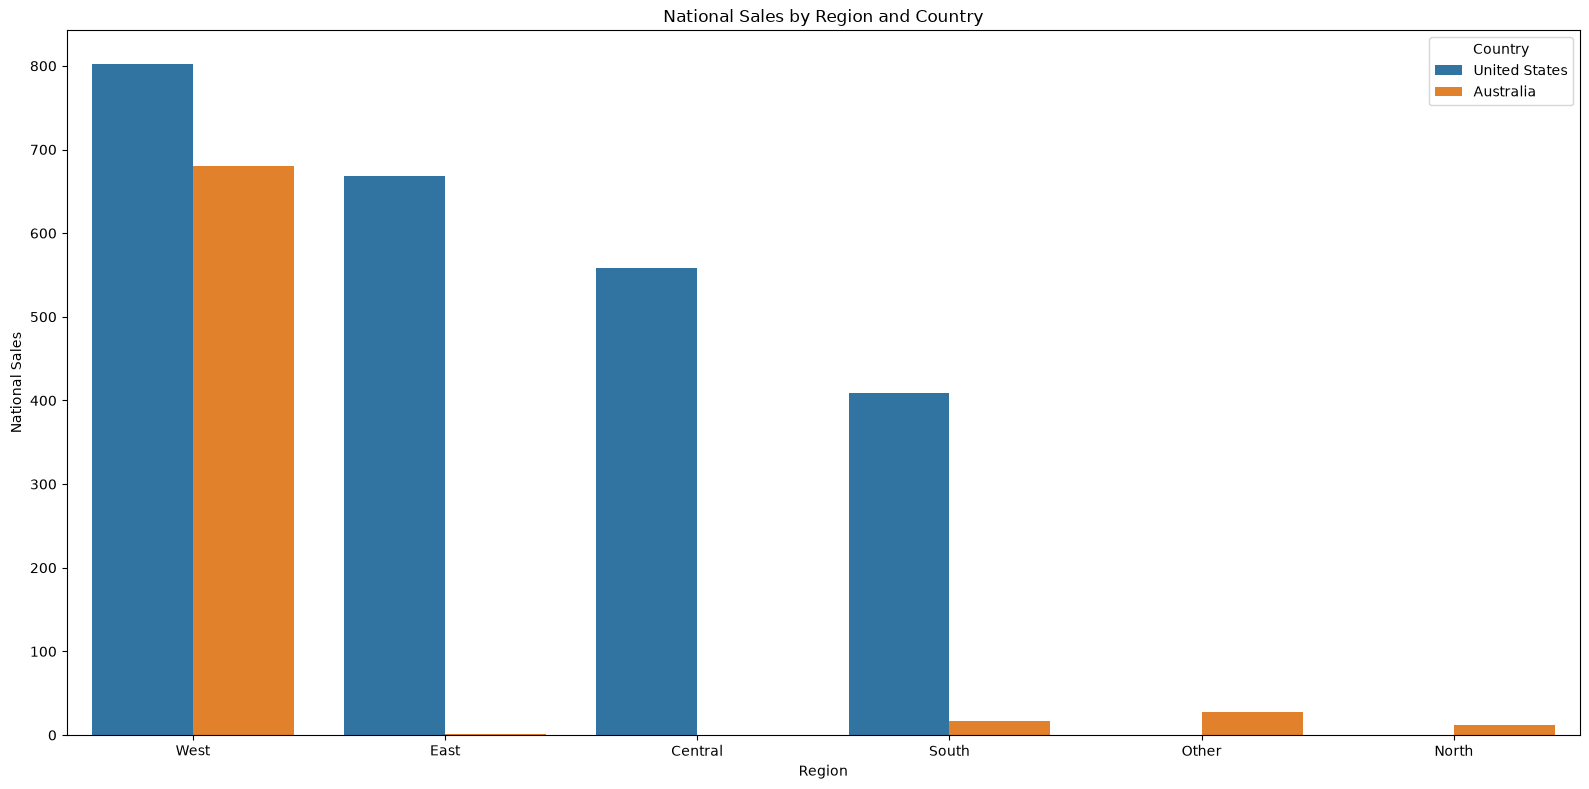

In [30]:
plt.figure(figsize = (16, 8))

sns.barplot(data = national_sales,
            x = 'Region',
            y = 'National_Sales',
            hue = 'Country')

plt.title('National Sales by Region and Country')
plt.xlabel('Region')
plt.ylabel('National Sales')
plt.tight_layout()

**Insight:**  
- The West region records the highest sales for both the United States (~802 million) and Australia (~681 million), with relatively similar sales figures.
- The East and Central regions are almost entirely dominated by the United States, with Australia contributing little to no sales.
- Australia's sales are primarily concentrated in the West, Other, and South regions, with minimal sales recorded in the East, Central, and North regions.
- This means Region and Country are interdependent; each country has higher sales in certain specific regions rather than an even distribution across all regions.

## Best Selling Genres

In [31]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
genre_sales

Genre
Action          1521.16
Sports          1152.19
Shooter          960.62
Role-Playing     816.66
Platform         777.48
Misc             669.99
Racing           640.94
Fighting         388.56
Simulation       332.94
Puzzle           205.32
Adventure        158.12
Strategy         128.95
Name: Global_Sales, dtype: float64

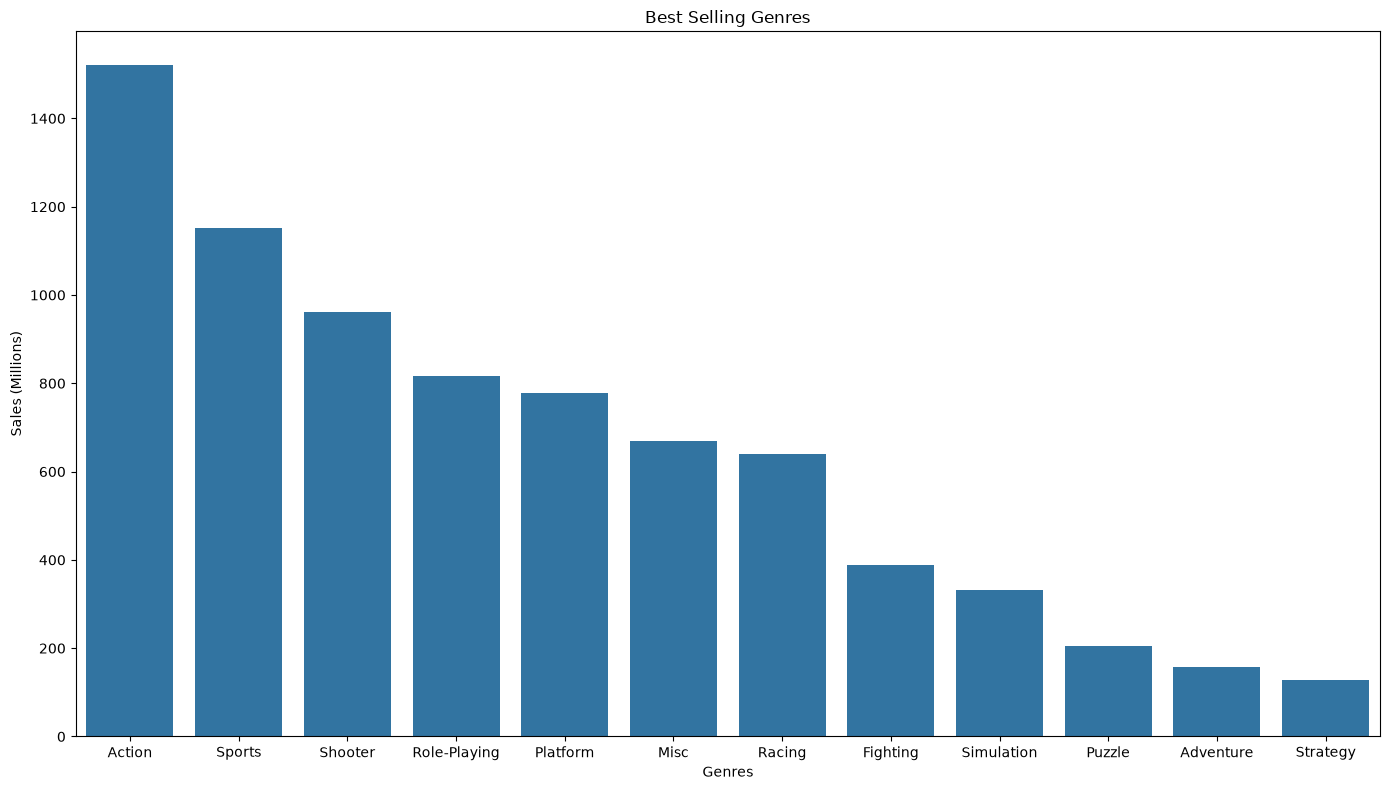

In [32]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x = genre_sales.index,
    y = genre_sales.values
)

plt.title('Best Selling Genres')
plt.xlabel("Genres")
plt.ylabel('Sales (Millions)')
plt.tight_layout()

**Insight:**   
- With approximately 1,521 million units in Global Sales, Action is the best-selling genre, outperforming Sports (the second-ranked genre) by roughly 370 million units.
- Sports and Shooter rank second and third, respectively, following Action.
- Strategy and Adventure are the two lowest-selling genres in the dataset.
- The gap among the top five genres (from Action to Platform) is relatively small, whereas a more pronounced decline is observed from Misc onward.

## Outlier Detection

### by Country

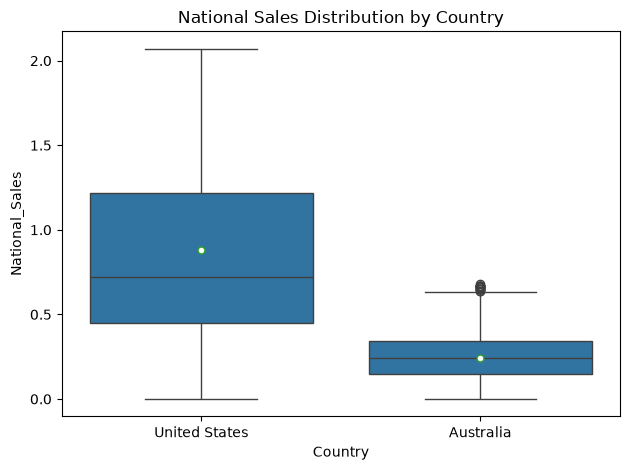

In [33]:
sns.boxplot(data = df,
            x = 'Country',
            y = 'National_Sales', 
            showmeans = True,
            meanprops = {
                'marker':'o',
                'markerfacecolor':'white',
                'markersize':'5'
            })

plt.title('National Sales Distribution by Country')
plt.tight_layout()

**Insight:**  
- The United States has a significantly higher median National Sales than Australia.  
- Sales in the United States show much greater variability, indicating a wider range of game performance.  
- Australia's sales are concentrated within a relatively narrow range, suggesting a more consistent but smaller market.  
- Although Australia contains several high-selling outliers, they remain well below the highest sales observed in the United States.

### by Genre

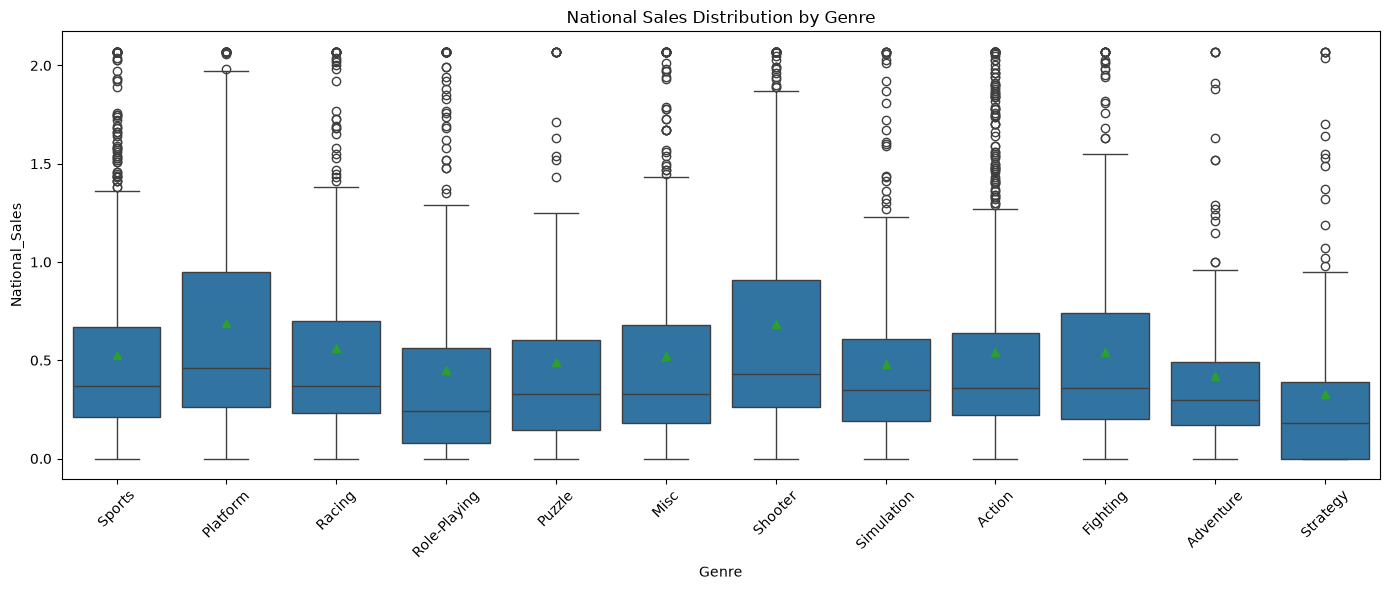

In [34]:
plt.figure(figsize=(14, 6))

sns.boxplot(data = df,
            x='Genre', 
            y='National_Sales',
            showmeans=True)

plt.title('National Sales Distribution by Genre')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:**  
- Platform and Shooter games have the highest median National Sales among all genres.  
- Strategy and Role-Playing games exhibit lower median sales compared to most other genres.  
- Shooter, Platform, and Fighting genres display greater variability, indicating a mix of both low- and high-performing titles.  
- Every genre contains high-value outliers, showing that blockbuster games can emerge regardless of genre.

## National and Global Sales by Country

In [35]:
sales = df.groupby(['Country'])[['National_Sales', 'Global_Sales']].sum().reset_index()
sales

,Country,National_Sales,Global_Sales
0,Australia,738.10,1456.51
1,United States,2437.99,6296.42


In [36]:
country = sales['Country']

nat_sales = sales['National_Sales']

glo_sales = sales['Global_Sales']

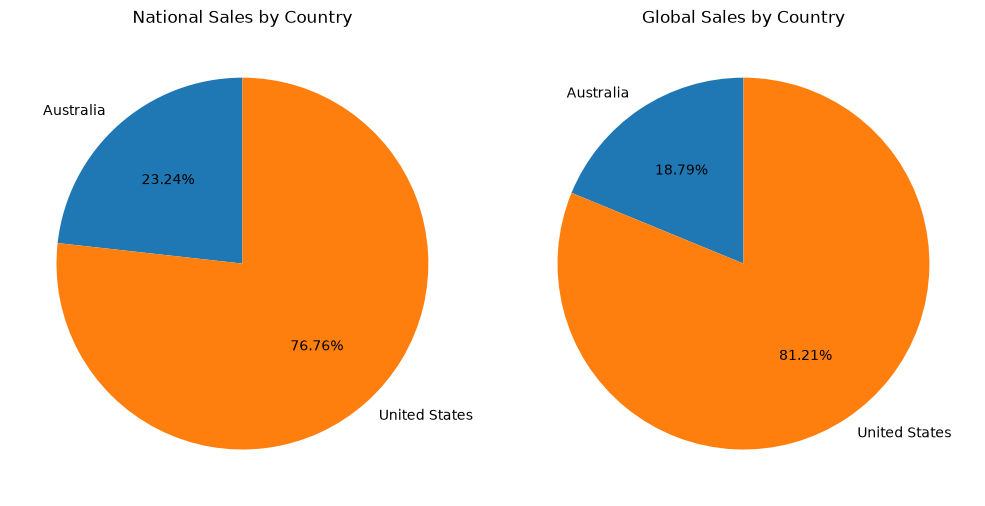

In [37]:
fig, axs = plt.subplots(1, 2, figsize = (10, 7))

axs[0].pie(nat_sales, labels = country, 
           autopct = "%.2f%%", startangle = 90)
axs[0].set_title('National Sales by Country')

axs[1].pie(glo_sales, labels = country, 
           autopct = "%.2f%%", startangle = 90)
axs[1].set_title('Global Sales by Country')

plt.tight_layout()

**Insight:**  
- The United States accounts for the majority of both National Sales (76.76%) and Global Sales (81.21%), highlighting its dominant position in the video game market.  
- Australia's share is considerably smaller in both metrics, indicating a more limited contribution to overall sales.  
- The United States contributes a higher proportion to Global Sales than to National Sales, suggesting its strong influence extends beyond its domestic market.  
- The sales distribution is highly concentrated, with the United States generating more than three-quarters of total sales in both categories.

## Relationship Between Global Sales and Global Profit

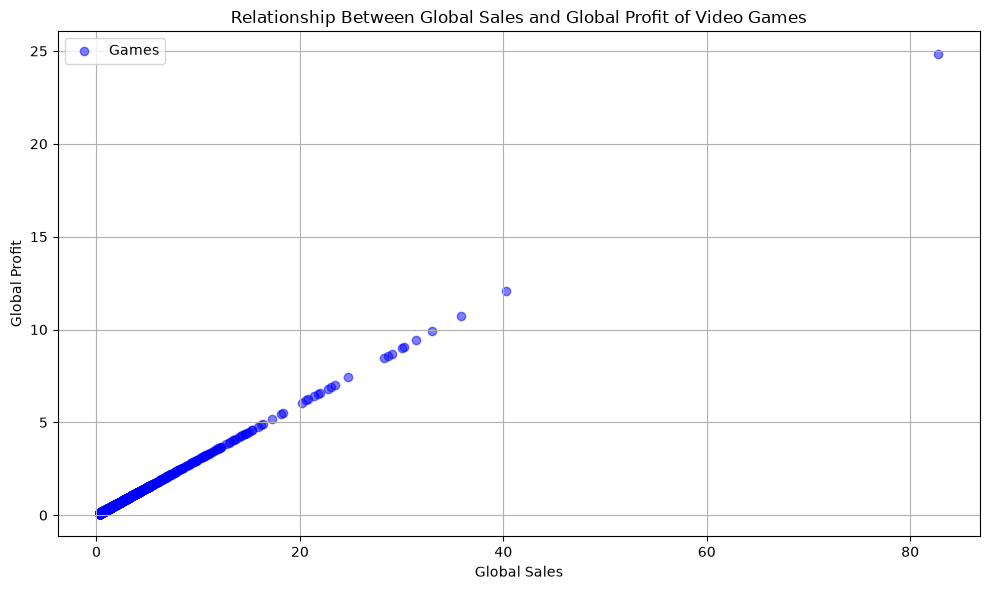

In [38]:
plt.figure(figsize = (10, 6))

plt.scatter(df['Global_Sales'],
            df['Global_Profit'],
            marker = 'o',
            color = 'b', alpha=0.5,
            label = 'Games')


plt.title("Relationship Between Global Sales and Global Profit of Video Games")
plt.xlabel('Global Sales')
plt.ylabel('Global Profit')
plt.legend()

plt.grid(True)
plt.tight_layout()

**Insight:**  
- Global Sales and Global Profit exhibit a strong positive linear relationship, indicating that higher-selling games generally generate higher profits.  
- Most games are clustered in the lower-left corner of the plot, suggesting that the majority achieve relatively low sales and profits.  
- A small number of blockbuster games stand out as extreme outliers, contributing disproportionately to total sales and profit.  
- No significant deviations from the overall positive trend are observed, indicating a consistent relationship between sales and profit across the dataset.

## Sales by Year

In [39]:
sales_by_year = df.groupby(['Year'])['Global_Sales'].sum().reset_index()
sales_by_year

,Year,Global_Sales
0,2010,3726.98
1,2011,1221.27
2,2012,973.94
3,2013,421.15
4,2014,476.11
5,2015,544.57
6,2016,230.88
7,2017,158.03


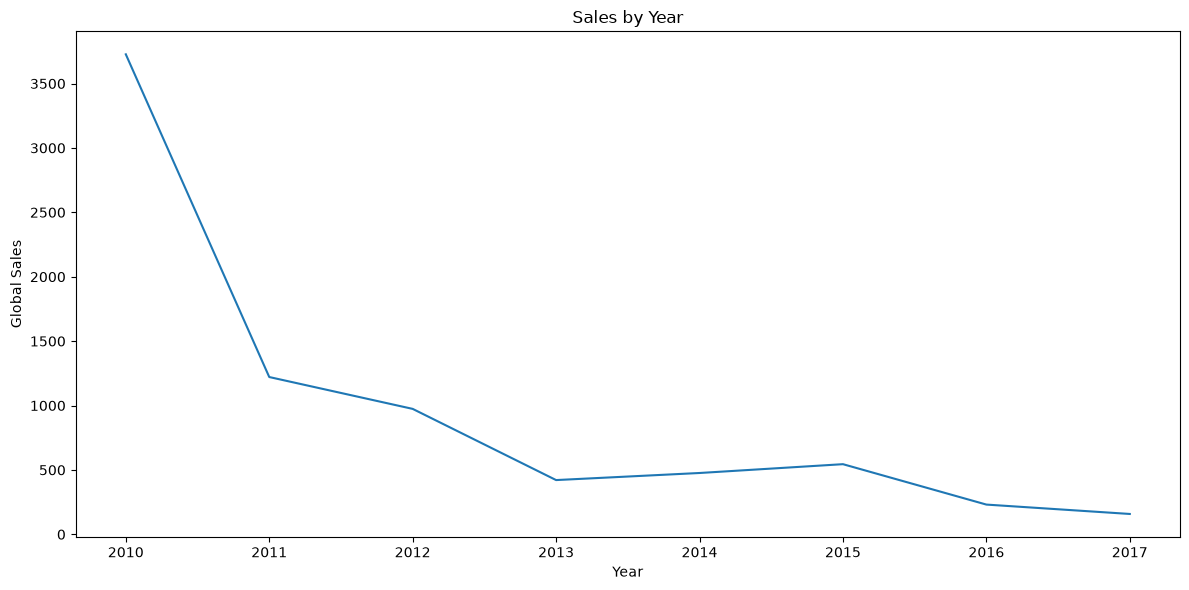

In [40]:
fig = plt.figure(figsize = (12, 6))

plt.plot(sales_by_year['Year'],
         sales_by_year['Global_Sales'])

plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.tight_layout()

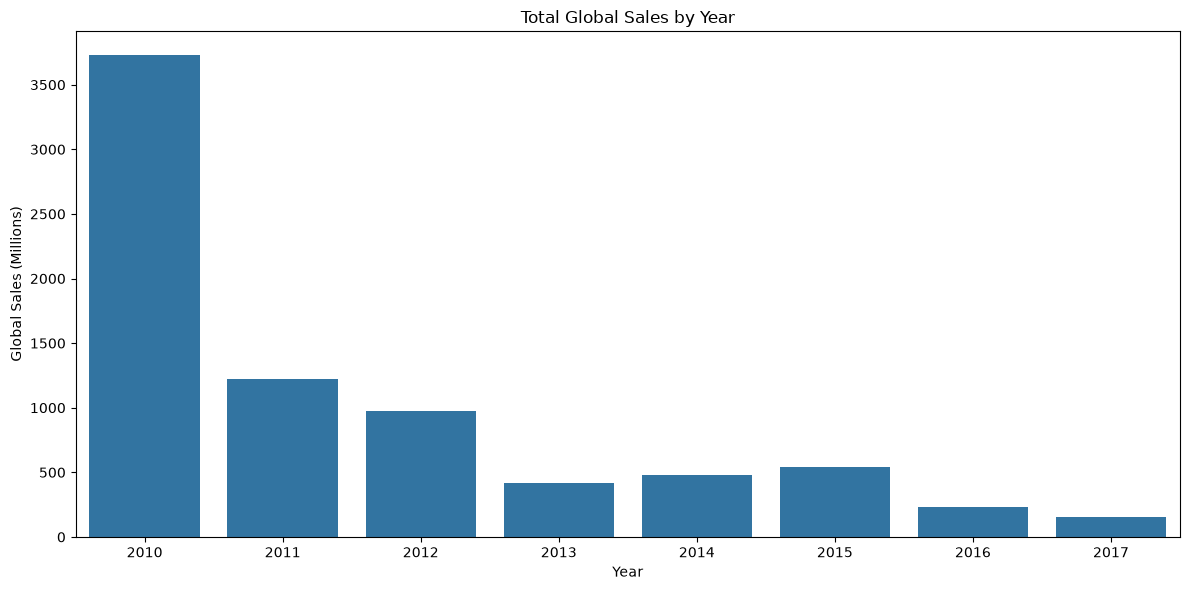

In [41]:
plt.figure(figsize = (12, 6))


sns.barplot(data = sales_by_year,
            x = 'Year',
            y = 'Global_Sales')

plt.title('Total Global Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.tight_layout()

**Insight:**  
- Global Sales peaked in 2010 and declined sharply in the following years.  
- After the initial decline, sales experienced a modest recovery around 2015 before continuing to decrease.  
- The overall trend indicates a significant downward movement in Global Sales over the observed period.  
- The decline suggests that the market generated substantially lower total sales in later years compared to the beginning of the period.

## Top 10 Best-Selling Games of All Time

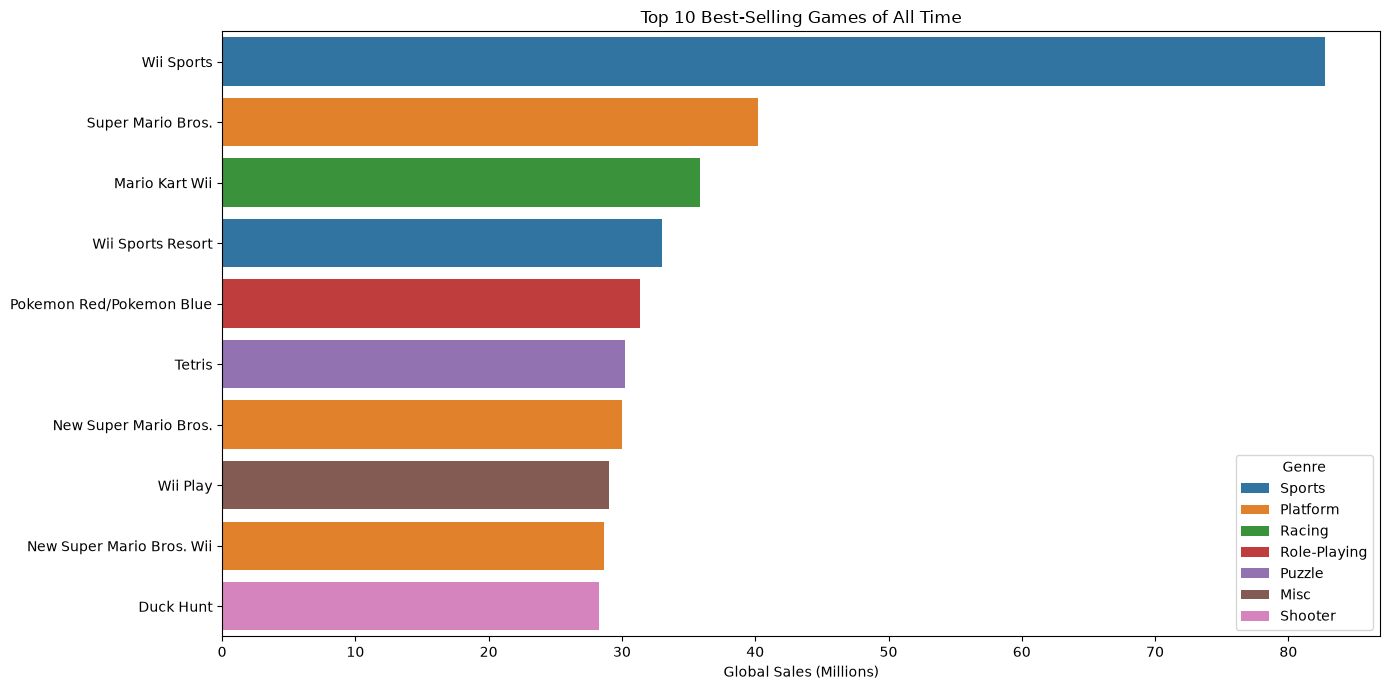

In [42]:
top_10 = df.nlargest(10, 'Global_Sales')

plt.figure(figsize = (14, 7))

sns.barplot(data = top_10,
            x = 'Global_Sales',
            y = 'Name',
            hue = 'Genre',
            dodge=False)

plt.title('Top 10 Best-Selling Games of All Time')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('')
plt.tight_layout()

**Insight:**  
- Wii Sports is the best-selling game by a substantial margin, significantly outperforming every other title in the dataset.  
- Nintendo-developed franchises dominate the top 10 list, highlighting the company's strong presence in the best-selling games of all time.  
- Platform and Sports games appear frequently among the top-selling titles, suggesting these genres have historically achieved strong commercial success.  
- The gap between the first-ranked game and the remaining titles indicates that only a few games achieve exceptional global sales. 
- The top-selling games represent multiple genres, indicating that blockbuster success is not limited to a single genre.  

## Best-Selling Months

In [43]:
month = df.groupby(['Month'])['Global_Sales'].sum().reset_index().sort_values(by = 'Global_Sales', ascending = False)
month

,Month,Global_Sales
4,Jan,703.81
3,Feb,661.07
7,Mar,649.35
0,Apr,649.07
8,May,644.48
6,Jun,641.39
5,Jul,639.93
1,Aug,638.38
11,Sep,637.40
10,Oct,633.66


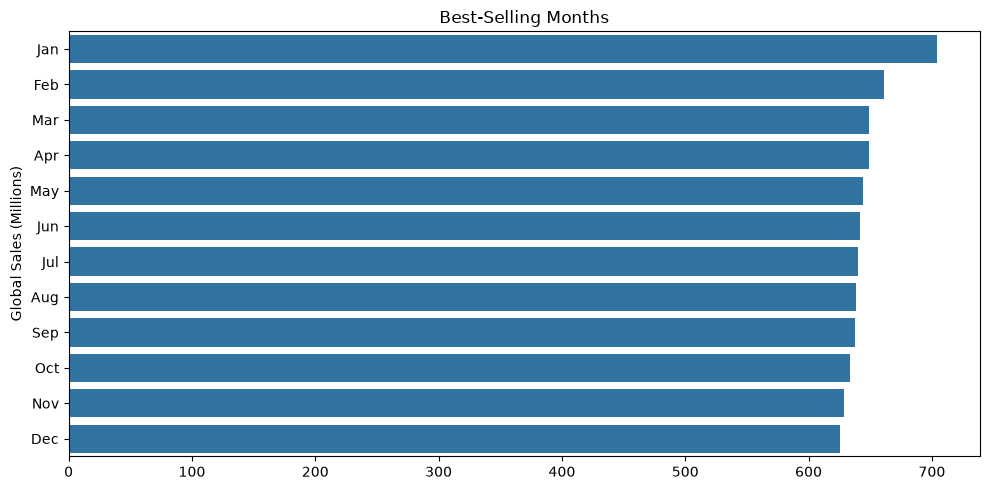

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(data=month,
            y='Month',
            x='Global_Sales',
            dodge=False)

plt.title('Best-Selling Months')
plt.xlabel('')
plt.ylabel('Global Sales (Millions)')
plt.tight_layout()

**Insight:**  
- January recorded the highest total Global Sales among all months.  
- Global Sales gradually declined after January, with relatively small differences between the remaining months.  
- The variation in total sales across most months is relatively modest, indicating a fairly stable monthly sales distribution.  
- December recorded the lowest total Global Sales within the observed period.

## Top 10 Publishers by Global Sales

In [45]:
top_10_publishers_by_global_sales = df.groupby(['Publisher'])['Global_Sales'].sum().nlargest(10).reset_index()
top_10_publishers_by_global_sales

,Publisher,Global_Sales
0,Nintendo,1760.48
1,Electronic Arts,1040.04
2,Activision,655.96
3,Sony Computer Entertainment,567.60
4,Ubisoft,404.56
5,Take-Two Interactive,372.58
6,THQ,284.70
7,Microsoft Game Studios,236.57
8,Sega,224.58
9,Konami Digital Entertainment,216.22


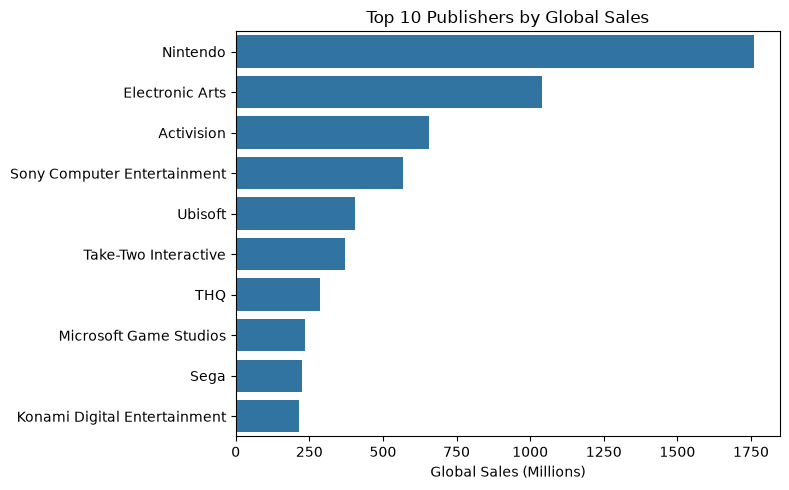

In [46]:
fig = plt.figure(figsize = (8,5))

sns.barplot(data = top_10_publishers_by_global_sales,
           x = 'Global_Sales',
           y = 'Publisher')

plt.title('Top 10 Publishers by Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('')
plt.tight_layout()

**Insight:**  
- Nintendo is the leading publisher by a significant margin, generating substantially higher Global Sales than any other publisher in the dataset.  
- Electronic Arts ranks second, but its total Global Sales remain considerably lower than Nintendo's.  
- The top publishers account for a large share of total Global Sales, indicating that market success is concentrated among a relatively small number of companies.  
- A noticeable gap exists between the top four publishers and the remaining companies, highlighting differences in market performance.  
- The distribution suggests a competitive market where only a few publishers consistently achieve exceptionally high sales.

## Correlation Heatmap

In [47]:
numerical_df = df.select_dtypes(include=["number"])
numerical_df.head()

,Rank,Year,National_Sales,Global_Sales,National_Profit,Global_Profit
0,1,2010,2.07,82.74,12.447,24.822
1,2,2010,2.07,40.24,8.724,12.072
2,3,2010,2.07,35.82,4.755,10.746
3,4,2010,2.07,33.00,4.725,9.900
4,5,2010,2.07,31.37,3.381,9.411


In [48]:
correlation_matrix = numerical_df.corr()
correlation_matrix

,Rank,Year,National_Sales,Global_Sales,National_Profit,Global_Profit
Rank,1.000000,0.865797,-0.734415,-0.494815,-0.452026,-0.494815
Year,0.865797,1.000000,-0.618781,-0.419890,-0.382179,-0.419890
National_Sales,-0.734415,-0.618781,1.000000,0.601505,0.661618,0.601505
Global_Sales,-0.494815,-0.419890,0.601505,1.000000,0.933371,1.000000
National_Profit,-0.452026,-0.382179,0.661618,0.933371,1.000000,0.933371
Global_Profit,-0.494815,-0.419890,0.601505,1.000000,0.933371,1.000000


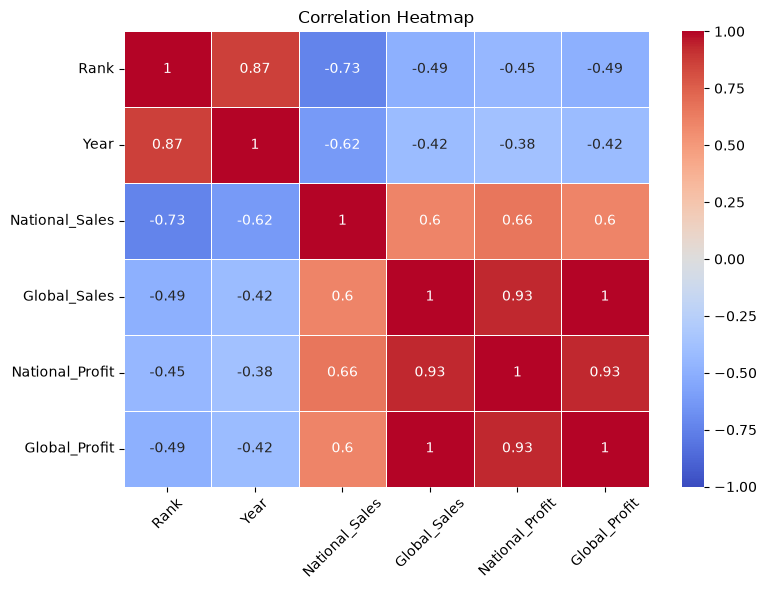

In [49]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot = True,  
    cmap = "coolwarm",  
    vmin = -1,
    vmax = 1, 
    linewidths = 0.5)

plt.title("Correlation Heatmap")
plt.xticks(rotation = 45)
plt.tight_layout()

**Insight:**  
- Global Sales and Global Profit have a nearly perfect positive correlation (1.00), indicating that higher global sales are strongly associated with higher global profits.  
- National Profit also shows a very strong positive correlation with Global Sales (0.93), suggesting that successful games tend to perform well across different markets.  
- National Sales has a moderate positive correlation with both Global Sales (0.60) and National Profit (0.66), indicating that domestic sales contribute to overall commercial success.  
- Rank is negatively correlated with all sales and profit metrics, meaning higher-ranked games (lower rank values) generally achieve greater sales and profits.  
- Year has a moderate negative correlation with sales and profit variables, suggesting that games released in later years tend to have lower recorded sales within this dataset.